In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
%matplotlib inline

In [2]:
DEBUG=1

Algorytm Bresenhama


In [3]:
def bresenham(x0,y0,x1,y1):
    points = []
    
    delta_x = abs(x1 - x0)
    delta_y = abs(y1 - y0)
    
    direction_x = 1 if x0 < x1 else -1
    direction_y = 1 if y0 < y1 else -1
    
    error = delta_x - delta_y

    while True:
        points.append((x0, y0))
        
        if x0 == x1 and y0 == y1:
            break
            
        error_x2 = 2 * error
        
        #horizontal move
        if error_x2 > -delta_y:
            error -= delta_y
            x0 += direction_x
            
        #vertical mvoe
        if error_x2 < delta_x:
            error += delta_x
            y0 += direction_y
            
    return points

wyznaczanie sinogramu


In [ ]:
def generate_sinogram(bitmap, angles, n_detectors, l_degrees):
    H,W = bitmap.shape
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    R = min(W, H) / 2.0 
    
    sinogram = np.zeros((len(angles), n_detectors))
    max_offset = R * np.sin(np.radians(l_degrees / 2.0))
    offsets = np.linspace(-max_offset, max_offset, n_detectors)
    t = int(np.ceil(max(W, H) * np.sqrt(2)))
    
    for i, alpha_deg in enumerate(angles):
        alpha = np.radians(alpha_deg)
        cos_a, sin_a = np.cos(alpha), np.sin(alpha)
        dx_p, dy_p   = -sin_a, cos_a

        for j, offset in enumerate(offsets):
            mx = cx + offset * dx_p
            my = cy + offset * dy_p

            t  = max(W, H)
            x0 = int(round(mx - t * cos_a))
            y0 = int(round(my - t * sin_a))
            x1 = int(round(mx + t * cos_a))
            y1 = int(round(my + t * sin_a))

            pixels = bresenham(x0, y0, x1, y1)

            sinogram[i, j] = sum(
                bitmap[py, px]
                for px, py in pixels
                if 0 <= px < W and 0 <= py < H  
            )
    sinogram /= sinogram.max()
    return sinogram

Rekonstrukcja


In [ ]:
def backproject(sinogram, angles, n_detectors, l_degrees, H, W):
    reconstruction = np.zeros((H, W))
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    
    x = np.linspace(-cx, W - 1 - cx, W)
    y = np.linspace(-cy, H - 1 - cy, H)
    X, Y = np.meshgrid(x, y)

    R = min(W, H) / 2.0
    R_limit  = R * np.sin(np.radians(l_degrees / 2.0)) 
    det_idx  = np.arange(n_detectors, dtype=np.float64)

    for i, alpha_deg in enumerate(angles):
        alpha = np.radians(alpha_deg)
        s     = X * np.cos(alpha) + Y * np.sin(alpha)
        idx   = (s + R_limit) * (n_detectors - 1) / (2.0 * R_limit)
        proj  = np.interp(idx.ravel(), det_idx, sinogram[i], left=0.0, right=0.0)
        reconstruction += proj.reshape(H, W)

    mx = reconstruction.max()
    if mx > 0:
        reconstruction /= mx
    return reconstruction

Parametry


Getting [0...1] bitmap from image

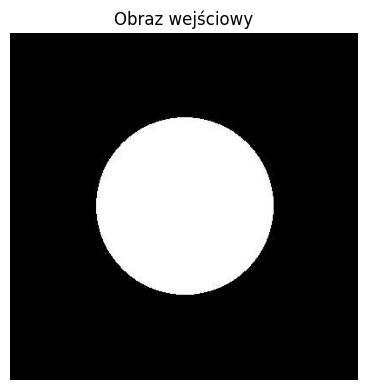

In [6]:
img = Image.open("img/Kolo.jpg")

grayscale_img = img.convert("L")
bitmap = np.array(grayscale_img)/255

H, W = bitmap.shape

if DEBUG == 1:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(bitmap, cmap='gray', vmin=0, vmax=1)
    ax.set_title('Obraz wejściowy')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

Settings


In [ ]:
style  = {'description_width': '140px'}
layout = widgets.Layout(width='500px')

slider_a_delta = widgets.FloatSlider(value=1.0, min=0.5, max=5.0, step=0.5,
    description='delta_a [st]', continuous_update=False, style=style, layout=layout)
slider_n_detectors  = widgets.IntSlider(value=180, min=90, max=360, step=10,
    description='n detektorow',  continuous_update=False, style=style, layout=layout)
slider_l_degrees     = widgets.IntSlider(value=180, min=10, max=360, step=5,
    description='l [st]',        continuous_update=False, style=style, layout=layout)
slider_level  = widgets.IntSlider(value=1, min=1, max=180, step=1,
    description='Postep katow:', continuous_update=False,
    style={'description_width': '120px'}, layout=widgets.Layout(width='500px'),
    disabled=True)

btn_gen  = widgets.Button(description='Generuj', button_style='primary',
    layout=widgets.Layout(width='120px'))
btn_full = widgets.Button(description='Pelny wynik', button_style='success',
    layout=widgets.Layout(width='130px'), disabled=True)
progress   = widgets.IntProgress(value=0, min=0, max=100, description='Postep:',
    bar_style='info', layout=widgets.Layout(width='500px'))
status_lbl = widgets.Label(value='Ustaw parametry i kliknij Generuj')

out = widgets.Output()

state = dict(sinogram=None, angles=None, n_det=None, l=None)


def rysuj(sino, rec, n, total):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(bitmap, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Oryginal'); axes[0].axis('off')
    axes[1].imshow(sino, cmap='gray', aspect='auto', vmin=0, vmax=1)
    axes[1].set_title(f'Sinogram ({n}/{total} katow)')
    axes[1].set_xlabel('detektor'); axes[1].set_ylabel('kat')
    axes[2].imshow(rec, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'Rekonstrukcja ({n}/{total} katow)'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()


def on_gen(b):
    angles = np.arange(0, 180, float(slider_a_delta.value))
    n_det  = int(slider_n_detectors.value)
    l_deg  = float(slider_l_degrees.value)
    total  = len(angles)

    btn_gen.disabled = True
    slider_level.disabled = True
    btn_full.disabled = True
    progress.max = total; progress.value = 0
    status_lbl.value = 'Sinogram...'

    sino = generate_sinogram(bitmap, angles, n_det, l_deg)
    progress.value = total // 2
    status_lbl.value = 'Rekonstrukcja...'
    rec = backproject(sino, angles, n_det, l_deg, H, W)
    progress.value = total

    state.update(sinogram=sino, angles=angles, n_det=n_det, l=l_deg)
    slider_level.max = total
    slider_level.value = total
    slider_level.disabled = False
    btn_full.disabled = False
    btn_gen.disabled = False
    status_lbl.value = f'Gotowe  {total} katow | {n_det} det | l={l_deg:.0f}st'


def on_prog(change):
    if state['sinogram'] is None:
        return
    n      = min(change['new'], len(state['angles']))
    sino_n = state['sinogram'][:n]
    rec_n  = backproject(sino_n, state['angles'][:n], state['n_det'], state['l'], H, W)
    with out:
        clear_output(wait=True)
        rysuj(sino_n, rec_n, n, len(state['angles']))


def on_full(b):
    if state['angles'] is not None:
        slider_level.value = len(state['angles'])


btn_gen.on_click(on_gen)
slider_level.observe(on_prog, names='value')
btn_full.on_click(on_full)

display(widgets.VBox([
    widgets.HTML('<b>Parametry ukladu</b>'),
    slider_a_delta, slider_n_detectors, slider_l_degrees,
    widgets.HBox([btn_gen, widgets.Label('   '), status_lbl]),
    progress,
    widgets.HBox([slider_level, btn_full]),
    out,
]))